In [1]:
from __future__ import annotations

import os
import time
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Make repo imports work from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)  # stabilize cwd

print("Project root:", PROJECT_ROOT)
print("Data exists:", (PROJECT_ROOT / "data").exists())
print("Results exists:", (PROJECT_ROOT / "results").exists())

# Local imports from QAOA framework
from ModularQaoaSetup.qaoa_solvers.core import discover_parquet_files, load_weighted_graph
from ModularQaoaSetup.partitioning_methods.strategies import build_partition_schedule
from ModularQaoaSetup.qaoa_solvers.modular import ModularSolveConfig, solve_graph_modular
from ModularQaoaSetup.benchmarking import benchmark_modular_run

Project root: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/Q-volution/Rigetti/energy-grid-qaoa
Data exists: True
Results exists: True


In [2]:
# Load Big dataset

DATA_DIR = PROJECT_ROOT / "data"
parquets = discover_parquet_files(DATA_DIR)
assert parquets, f"No parquet files found in {DATA_DIR}"

path = parquets[-1]  # largest by file size
print("Using parquet:", path.name, "| size MB:", path.stat().st_size / 1e6)

G = load_weighted_graph(path)
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

# Quick sanity on weights
w = np.array([d["weight"] for *_, d in G.edges(data=True)], dtype=float)
print("Weight stats:", dict(min=float(w.min()), max=float(w.max()), mean=float(w.mean()), median=float(np.median(w))))

Using parquet: dataset_b.parquet | size MB: 0.003775
Nodes: 180 Edges: 226
Weight stats: {'min': 7.825488382367, 'max': 119.895996514071, 'mean': 33.03410392179372, 'median': 30.0937203085005}


Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/Q-volution/Rigetti/energy-grid-qaoa/results/00_graph_spring.png


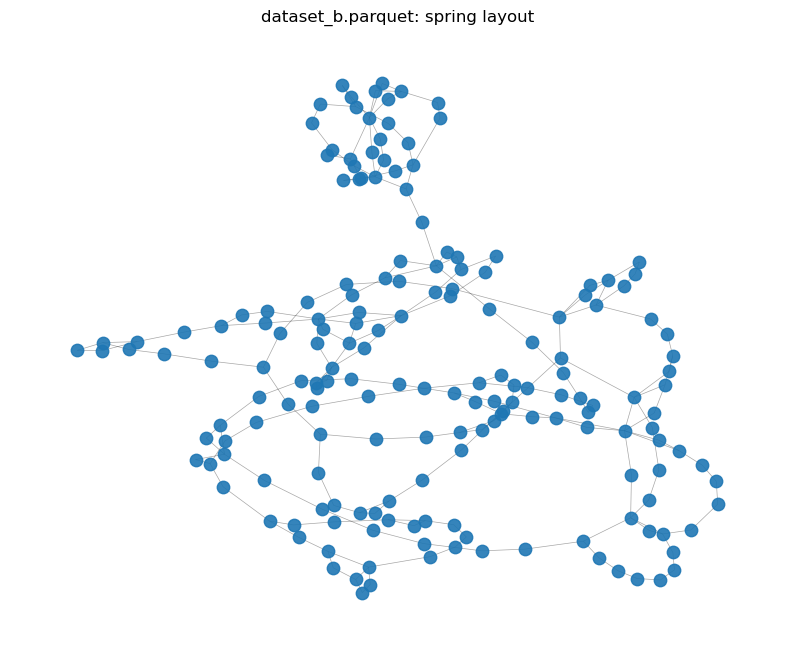

In [3]:
# Visualize the graph

def draw_graph(G, title="", node_color=None, node_size=80, with_labels=False, seed=7, save=None):
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=seed, k=1/np.sqrt(max(1, G.number_of_nodes())))
    nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size, alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.35)
    if with_labels:
        nx.draw_networkx_labels(G, pos, font_size=7)
    plt.title(title)
    plt.axis("off")
    if save:
        out = PROJECT_ROOT / "results" / save
        plt.savefig(out, dpi=200, bbox_inches="tight")
        print("Saved:", out)
    plt.show()

draw_graph(G, title=f"{path.name}: spring layout", save="00_graph_spring.png")

Region blocks: 18 max block: 16
Boundary blocks: 30 max block: 8
Coarse nodes: 18 coarse edges: 25
Boundary nodes: 73
Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/Q-volution/Rigetti/energy-grid-qaoa/results/01_boundary_nodes.png


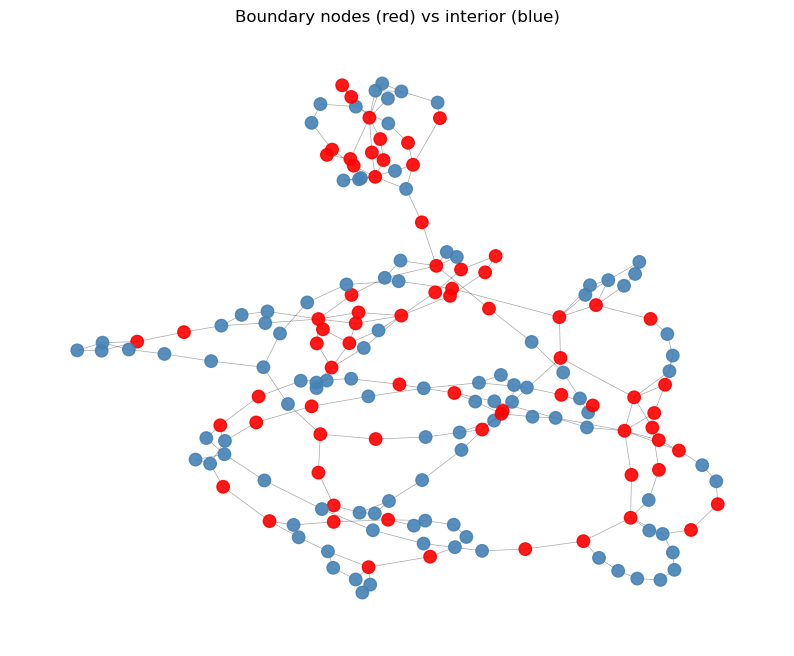

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/Q-volution/Rigetti/energy-grid-qaoa/results/02_coarse_graph.png


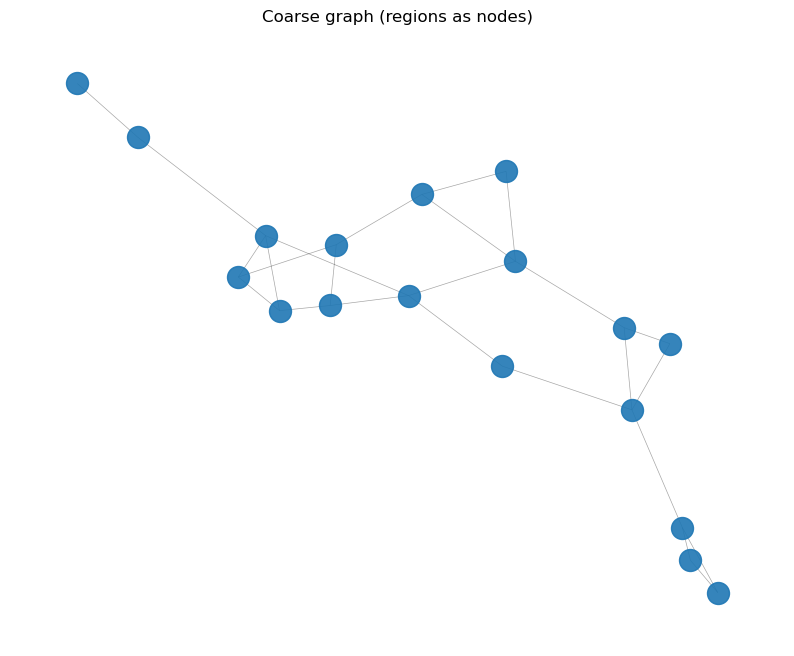

In [4]:
# Partition schedule + boundary graph + coarse graph

cfg_partition = dict(strategy="multilevel", max_block_size=16, seed=7)  # tweak block size later
schedule = build_partition_schedule(G, **cfg_partition)

region_blocks = schedule.region_blocks
boundary_blocks = schedule.boundary_blocks
layout = schedule.layout

print("Region blocks:", len(region_blocks), "max block:", max(len(b) for b in region_blocks))
print("Boundary blocks:", len(boundary_blocks), "max block:", max(len(b) for b in boundary_blocks) if boundary_blocks else 0)

boundary_nodes = set()
if layout is not None:
    boundary_nodes = set(layout.boundary_nodes)
    print("Coarse nodes:", layout.coarse_graph.number_of_nodes(), "coarse edges:", layout.coarse_graph.number_of_edges())
    print("Boundary nodes:", len(boundary_nodes))

# Color boundary nodes red
colors = ["red" if n in boundary_nodes else "steelblue" for n in G.nodes()]
draw_graph(G, title="Boundary nodes (red) vs interior (blue)", node_color=colors, save="01_boundary_nodes.png")

# Visualize coarse graph if present
if layout is not None:
    draw_graph(layout.coarse_graph, title="Coarse graph (regions as nodes)", node_size=250, save="02_coarse_graph.png")

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/Q-volution/Rigetti/energy-grid-qaoa/results/03_regions.png


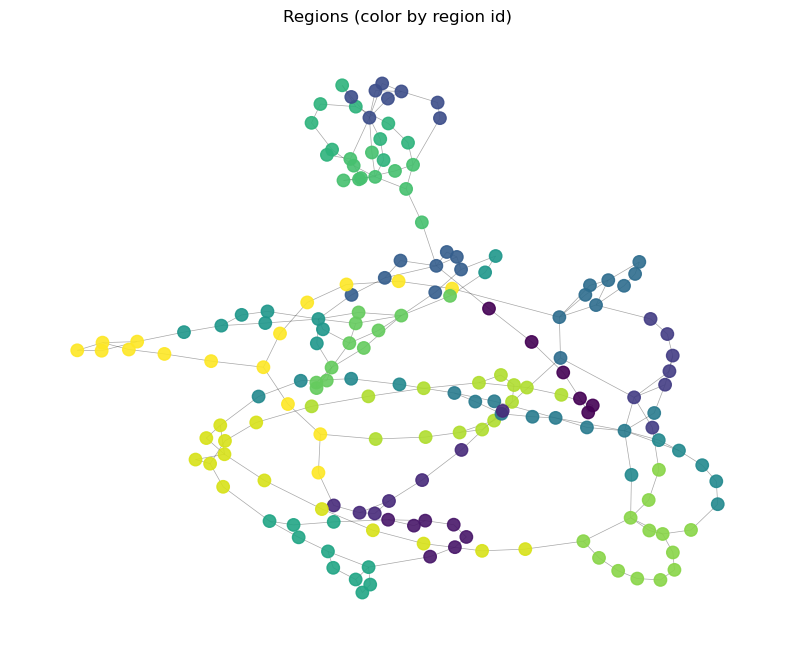

In [5]:
# Visualize region blocks (color by region)

# Assign each node a region id
node_to_region = {}
for rid, block in enumerate(region_blocks):
    for n in block:
        node_to_region[n] = rid

region_ids = np.array([node_to_region[n] for n in G.nodes()], dtype=int)
draw_graph(G, title="Regions (color by region id)", node_color=region_ids, save="03_regions.png")

In [6]:
# Baseline A: greedy_local modular (divide-and-conquer classical)

cfg_greedy = ModularSolveConfig(
    partition_strategy="multilevel",
    region_optimizer="greedy_local",
    boundary_optimizer="greedy_local",
    max_block_size=16,
    rounds=2,
    seed=7,
)

res_greedy = benchmark_modular_run(G, name=path.name, config=cfg_greedy, separate_timing_pass=False)
print(res_greedy.to_dict())

{'name': 'dataset_b.parquet', 'partition_strategy': 'multilevel', 'region_optimizer': 'greedy_local', 'boundary_optimizer': 'greedy_local', 'wall_time_s': 0.19083333401067648, 'cpu_time_s': 0.5188439999999996, 'weighted_cut': 6244.801568914778, 'ising_energy': -5023.895651504175, 'rounds_run': 2, 'evaluation_credits_total': 262504, 'quantum_evaluation_credits': 0, 'classical_evaluation_credits': 262504, 'quantum_block_updates': 0, 'quantum_statevector_evaluations': 0, 'quantum_objective_evaluations': 0, 'quantum_decode_evaluations': 0, 'quantum_simulated_amplitudes': 0, 'quantum_gate_amplitude_ops': 0, 'quantum_observable_amplitude_ops': 0, 'quantum_decode_amplitudes_scanned': 0, 'max_quantum_block_size': 0, 'classical_exact_block_updates': 0, 'classical_exact_state_evaluations': 0, 'classical_exact_tiebreak_state_evaluations': 0, 'classical_greedy_block_updates': 96, 'classical_local_search_passes': 2, 'classical_local_search_node_visits': 360, 'classical_local_search_edge_touches': 9

In [7]:
# Baseline B: one-shot global local search (no partition)

from ModularQaoaSetup.graph_ops import initial_assignment, greedy_refine, weighted_cut_value

a0 = initial_assignment(G, seed=7)
a1 = greedy_refine(G, a0, seed=7)
global_greedy_cut = weighted_cut_value(G, a1)
print("Global greedy_refine weighted_cut:", global_greedy_cut)

Global greedy_refine weighted_cut: 6778.186721732447


In [25]:
# Standard QAOA baseline (small p, block level)

cfg_std_qaoa = ModularSolveConfig(
    partition_strategy="multilevel",
    region_optimizer="standard_qaoa",
    boundary_optimizer="standard_qaoa",
    depth=1,          # p=1 baseline
    max_block_size=16,
    rounds=2,
    restarts=2,
    maxiter=25,
    seed=7,
    error_model="ideal",
)

res_std = benchmark_modular_run(G, name=path.name, config=cfg_std_qaoa, separate_timing_pass=False)
print(res_std.to_dict())

{'name': 'dataset_b.parquet', 'partition_strategy': 'multilevel', 'region_optimizer': 'standard_qaoa', 'boundary_optimizer': 'standard_qaoa', 'wall_time_s': 39.18996570800664, 'cpu_time_s': 229.38751599999978, 'weighted_cut': 7009.17760948767, 'ising_energy': -6552.6477326499635, 'rounds_run': 2, 'evaluation_credits_total': 271982, 'quantum_evaluation_credits': 9478, 'classical_evaluation_credits': 262504, 'quantum_block_updates': 96, 'quantum_statevector_evaluations': 9382, 'quantum_objective_evaluations': 9382, 'quantum_decode_evaluations': 96, 'quantum_simulated_amplitudes': 22046720, 'quantum_gate_amplitude_ops': 322970600, 'quantum_observable_amplitude_ops': 412835792, 'quantum_decode_amplitudes_scanned': 234184, 'max_quantum_block_size': 16, 'classical_exact_block_updates': 0, 'classical_exact_state_evaluations': 0, 'classical_exact_tiebreak_state_evaluations': 0, 'classical_greedy_block_updates': 0, 'classical_local_search_passes': 2, 'classical_local_search_node_visits': 360, '

In [10]:
# Comparison Table
"""
rows = []
for tag, r in [
    ("greedy_modular", res_greedy),
    ("std_qaoa_modular", res_std),
    ("precond_hybrid", res_pre),
]:
    d = r.to_dict()
    d["tag"] = tag
    rows.append(d)

df = pd.DataFrame(rows)[
    ["tag","weighted_cut","wall_time_s","cpu_time_s","rounds_run","partition_strategy","region_optimizer","boundary_optimizer",
     "blocks_total","light_cones_evaluated","two_qubit_pairs_evaluated"]
    if "blocks_total" in rows[0] else
    ["tag","weighted_cut","wall_time_s","cpu_time_s","rounds_run","partition_strategy","region_optimizer","boundary_optimizer"]
]
df = df.sort_values("weighted_cut", ascending=False)
df"""

'\nrows = []\nfor tag, r in [\n    ("greedy_modular", res_greedy),\n    ("std_qaoa_modular", res_std),\n    ("precond_hybrid", res_pre),\n]:\n    d = r.to_dict()\n    d["tag"] = tag\n    rows.append(d)\n\ndf = pd.DataFrame(rows)[\n    ["tag","weighted_cut","wall_time_s","cpu_time_s","rounds_run","partition_strategy","region_optimizer","boundary_optimizer",\n     "blocks_total","light_cones_evaluated","two_qubit_pairs_evaluated"]\n    if "blocks_total" in rows[0] else\n    ["tag","weighted_cut","wall_time_s","cpu_time_s","rounds_run","partition_strategy","region_optimizer","boundary_optimizer"]\n]\ndf = df.sort_values("weighted_cut", ascending=False)\ndf'

In [11]:
"""
out = PROJECT_ROOT / "results" / "benchmark_summary.csv"
df.to_csv(out, index=False)
print("Saved:", out)"""

'\nout = PROJECT_ROOT / "results" / "benchmark_summary.csv"\ndf.to_csv(out, index=False)\nprint("Saved:", out)'

In [13]:
from ModularQaoaSetup.qaoa_solvers.modular import ModularSolveConfig
from ModularQaoaSetup.benchmarking import benchmark_modular_run

cfg_pre_fast = ModularSolveConfig(
    partition_strategy="multilevel",
    region_optimizer="hybrid_preconditioned",
    boundary_optimizer="hybrid_preconditioned",
    depth=1,
    max_block_size=16,
    rounds=2,
    restarts=2,
    maxiter=25,
    seed=7,
    max_light_cone_size=16, 
    preconditioning_backend="greedy",
    preconditioner_shots=0,            # try 256, 512, 1024, 2048   
    preconditioner_use_pcut=True,
)

res_pre_fast = benchmark_modular_run(G, name=path.name, config=cfg_pre_fast, separate_timing_pass=False)
res_pre_fast.to_dict()

{'name': 'dataset_b.parquet',
 'partition_strategy': 'multilevel',
 'region_optimizer': 'hybrid_preconditioned',
 'boundary_optimizer': 'hybrid_preconditioned',
 'wall_time_s': 95.48390595801175,
 'cpu_time_s': 587.6475179999999,
 'weighted_cut': 6603.578988463026,
 'ising_energy': -5741.4504906006705,
 'rounds_run': 1,
 'evaluation_credits_total': 4877,
 'quantum_evaluation_credits': 4157,
 'classical_evaluation_credits': 720,
 'quantum_block_updates': 48,
 'quantum_statevector_evaluations': 4157,
 'quantum_objective_evaluations': 4157,
 'quantum_decode_evaluations': 0,
 'quantum_simulated_amplitudes': 63072624,
 'quantum_gate_amplitude_ops': 989996064,
 'quantum_observable_amplitude_ops': 1066550512,
 'quantum_decode_amplitudes_scanned': 0,
 'max_quantum_block_size': 16,
 'classical_exact_block_updates': 0,
 'classical_exact_state_evaluations': 0,
 'classical_exact_tiebreak_state_evaluations': 0,
 'classical_greedy_block_updates': 48,
 'classical_local_search_passes': 4,
 'classical_

In [14]:
from ModularQaoaSetup.qaoa_solvers.modular import ModularSolveConfig
from ModularQaoaSetup.benchmarking import benchmark_modular_run

cfg_pre_fast = ModularSolveConfig(
    partition_strategy="multilevel",
    region_optimizer="hybrid_preconditioned",
    boundary_optimizer="hybrid_preconditioned",
    depth=1,
    max_block_size=16,
    rounds=2,
    restarts=2,
    maxiter=25,
    seed=7,
    max_light_cone_size=16, 
    preconditioning_backend="greedy",
    preconditioner_shots=0,            # try 256, 512, 1024, 2048   
    preconditioner_use_pcut=False,
)

res_pre_fast = benchmark_modular_run(G, name=path.name, config=cfg_pre_fast, separate_timing_pass=False)
res_pre_fast.to_dict()

{'name': 'dataset_b.parquet',
 'partition_strategy': 'multilevel',
 'region_optimizer': 'hybrid_preconditioned',
 'boundary_optimizer': 'hybrid_preconditioned',
 'wall_time_s': 83.12017900000501,
 'cpu_time_s': 523.82113,
 'weighted_cut': 6451.467526498477,
 'ising_energy': -5437.227566671577,
 'rounds_run': 1,
 'evaluation_credits_total': 5237,
 'quantum_evaluation_credits': 4157,
 'classical_evaluation_credits': 1080,
 'quantum_block_updates': 48,
 'quantum_statevector_evaluations': 4157,
 'quantum_objective_evaluations': 4157,
 'quantum_decode_evaluations': 0,
 'quantum_simulated_amplitudes': 63072624,
 'quantum_gate_amplitude_ops': 989996064,
 'quantum_observable_amplitude_ops': 1066550512,
 'quantum_decode_amplitudes_scanned': 0,
 'max_quantum_block_size': 16,
 'classical_exact_block_updates': 0,
 'classical_exact_state_evaluations': 0,
 'classical_exact_tiebreak_state_evaluations': 0,
 'classical_greedy_block_updates': 48,
 'classical_local_search_passes': 6,
 'classical_local_se

In [15]:
from ModularQaoaSetup.qaoa_solvers.modular import ModularSolveConfig
from ModularQaoaSetup.benchmarking import benchmark_modular_run

cfg_pre_fast = ModularSolveConfig(
    partition_strategy="multilevel",
    region_optimizer="hybrid_preconditioned",
    boundary_optimizer="hybrid_preconditioned",
    depth=1,
    max_block_size=16,
    rounds=2,
    restarts=2,
    maxiter=25,
    seed=7,
    max_light_cone_size=20, 
    preconditioning_backend="greedy",
    preconditioner_shots=0,            # try 256, 512, 1024, 2048   
    preconditioner_use_pcut=True,
)

res_pre_fast = benchmark_modular_run(G, name=path.name, config=cfg_pre_fast, separate_timing_pass=False)
res_pre_fast.to_dict()

{'name': 'dataset_b.parquet',
 'partition_strategy': 'multilevel',
 'region_optimizer': 'hybrid_preconditioned',
 'boundary_optimizer': 'hybrid_preconditioned',
 'wall_time_s': 384.45328229200095,
 'cpu_time_s': 2400.414452,
 'weighted_cut': 6712.096884816909,
 'ising_energy': -5958.486283308438,
 'rounds_run': 1,
 'evaluation_credits_total': 5066,
 'quantum_evaluation_credits': 4166,
 'classical_evaluation_credits': 900,
 'quantum_block_updates': 48,
 'quantum_statevector_evaluations': 4166,
 'quantum_objective_evaluations': 4166,
 'quantum_decode_evaluations': 0,
 'quantum_simulated_amplitudes': 302999920,
 'quantum_gate_amplitude_ops': 5730739232,
 'quantum_observable_amplitude_ops': 6118524144,
 'quantum_decode_amplitudes_scanned': 0,
 'max_quantum_block_size': 20,
 'classical_exact_block_updates': 0,
 'classical_exact_state_evaluations': 0,
 'classical_exact_tiebreak_state_evaluations': 0,
 'classical_greedy_block_updates': 48,
 'classical_local_search_passes': 5,
 'classical_loca

In [26]:
from ModularQaoaSetup.qaoa_solvers.modular import ModularSolveConfig
from ModularQaoaSetup.benchmarking import benchmark_modular_run

cfg_pre_fast = ModularSolveConfig(
    partition_strategy="multilevel",
    region_optimizer="hybrid_preconditioned",
    boundary_optimizer="hybrid_preconditioned",
    depth=1,
    max_block_size=16,
    rounds=2,
    restarts=2,
    maxiter=25,
    seed=7,
    max_light_cone_size=16, 
    preconditioning_backend="burer_monteiro",
    preconditioner_shots=0,            # try 256, 512, 1024, 2048   
    preconditioner_use_pcut=True,
)

res_pre_fast = benchmark_modular_run(G, name=path.name, config=cfg_pre_fast, separate_timing_pass=False)
res_pre_fast.to_dict()

{'name': 'dataset_b.parquet',
 'partition_strategy': 'multilevel',
 'region_optimizer': 'hybrid_preconditioned',
 'boundary_optimizer': 'hybrid_preconditioned',
 'wall_time_s': 86.67553174999193,
 'cpu_time_s': 550.8515269999998,
 'weighted_cut': 7024.527986584479,
 'ising_energy': -6583.348486843578,
 'rounds_run': 2,
 'evaluation_credits_total': 36783,
 'quantum_evaluation_credits': 4157,
 'classical_evaluation_credits': 32626,
 'quantum_block_updates': 48,
 'quantum_statevector_evaluations': 4157,
 'quantum_objective_evaluations': 4157,
 'quantum_decode_evaluations': 0,
 'quantum_simulated_amplitudes': 63072624,
 'quantum_gate_amplitude_ops': 989996064,
 'quantum_observable_amplitude_ops': 1066550512,
 'quantum_decode_amplitudes_scanned': 0,
 'max_quantum_block_size': 16,
 'classical_exact_block_updates': 0,
 'classical_exact_state_evaluations': 0,
 'classical_exact_tiebreak_state_evaluations': 0,
 'classical_greedy_block_updates': 0,
 'classical_local_search_passes': 2442,
 'classi

In [30]:
import inspect
import random

from ModularQaoaSetup.graph_ops import burer_monteiro_refine, weighted_cut_value

# --- make a simple initial assignment (spin +/-1) ---
rng = random.Random(7)
assignment0 = {int(u): (1 if rng.random() < 0.5 else -1) for u in G.nodes()}

# --- call BM refine on the FULL graph (no preconditioning) ---
sig = inspect.signature(burer_monteiro_refine)
kwargs = {"seed": 7}

# common optional knobs (only passed if supported)
for k, v in {
    "rank": 8,
    "steps": 200,
    "learning_rate": 0.2,
    "rounding_trials": 64,
    "blocks": [list(G.nodes())],   # “divide & conquer” OFF: single block = whole graph
    "assignment": assignment0,     # in case it wants named arg
}.items():
    if k in sig.parameters:
        kwargs[k] = v

# burer_monteiro_refine may be in-place or may return an assignment; handle both
out = burer_monteiro_refine(G, assignment0, **{k:v for k,v in kwargs.items() if k != "assignment"}) \
      if "assignment" not in sig.parameters else burer_monteiro_refine(G, **kwargs)

assignment_bm = out if isinstance(out, dict) else assignment0

print("BM-only weighted_cut:", weighted_cut_value(G, assignment_bm))

BM-only weighted_cut: 7013.67809570958


In [31]:
from ModularQaoaSetup.qaoa_solvers.modular import ModularSolveConfig
from ModularQaoaSetup.benchmarking import benchmark_modular_run

cfg_pre_fast = ModularSolveConfig(
    partition_strategy="multilevel",
    region_optimizer="hybrid_preconditioned",
    boundary_optimizer="hybrid_preconditioned",
    depth=1,
    max_block_size=16,
    rounds=2,
    restarts=2,
    maxiter=25,
    seed=7,
    max_light_cone_size=20, 
    preconditioning_backend="burer_monteiro",
    preconditioner_shots=0,            # try 256, 512, 1024, 2048   
    preconditioner_use_pcut=True,
)

res_pre_fast = benchmark_modular_run(G, name=path.name, config=cfg_pre_fast, separate_timing_pass=False)
res_pre_fast.to_dict()

{'name': 'dataset_b.parquet',
 'partition_strategy': 'multilevel',
 'region_optimizer': 'hybrid_preconditioned',
 'boundary_optimizer': 'hybrid_preconditioned',
 'wall_time_s': 376.3881397080113,
 'cpu_time_s': 2290.303624,
 'weighted_cut': 7009.757368556917,
 'ising_energy': -6553.807250788453,
 'rounds_run': 2,
 'evaluation_credits_total': 36972,
 'quantum_evaluation_credits': 4166,
 'classical_evaluation_credits': 32806,
 'quantum_block_updates': 48,
 'quantum_statevector_evaluations': 4166,
 'quantum_objective_evaluations': 4166,
 'quantum_decode_evaluations': 0,
 'quantum_simulated_amplitudes': 302999920,
 'quantum_gate_amplitude_ops': 5730739232,
 'quantum_observable_amplitude_ops': 6118524144,
 'quantum_decode_amplitudes_scanned': 0,
 'max_quantum_block_size': 20,
 'classical_exact_block_updates': 0,
 'classical_exact_state_evaluations': 0,
 'classical_exact_tiebreak_state_evaluations': 0,
 'classical_greedy_block_updates': 0,
 'classical_local_search_passes': 2443,
 'classical_

In [32]:
from ModularQaoaSetup.qaoa_solvers.modular import ModularSolveConfig
from ModularQaoaSetup.benchmarking import benchmark_modular_run

cfg_pre_fast = ModularSolveConfig(
    partition_strategy="multilevel",
    region_optimizer="hybrid_preconditioned",
    boundary_optimizer="hybrid_preconditioned",
    depth=1,
    max_block_size=16,
    rounds=2,
    restarts=2,
    maxiter=25,
    seed=7,
    max_light_cone_size=17, 
    preconditioning_backend="burer_monteiro",
    preconditioner_shots=0,            # try 256, 512, 1024, 2048   
    preconditioner_use_pcut=True,
)

res_pre_fast = benchmark_modular_run(G, name=path.name, config=cfg_pre_fast, separate_timing_pass=False)
res_pre_fast.to_dict()

{'name': 'dataset_b.parquet',
 'partition_strategy': 'multilevel',
 'region_optimizer': 'hybrid_preconditioned',
 'boundary_optimizer': 'hybrid_preconditioned',
 'wall_time_s': 152.2773283340066,
 'cpu_time_s': 969.3443669999997,
 'weighted_cut': 7043.261860437179,
 'ising_energy': -6620.816234548979,
 'rounds_run': 2,
 'evaluation_credits_total': 36793,
 'quantum_evaluation_credits': 4167,
 'classical_evaluation_credits': 32626,
 'quantum_block_updates': 48,
 'quantum_statevector_evaluations': 4167,
 'quantum_objective_evaluations': 4167,
 'quantum_decode_evaluations': 0,
 'quantum_simulated_amplitudes': 102721904,
 'quantum_gate_amplitude_ops': 1702372384,
 'quantum_observable_amplitude_ops': 1817789680,
 'quantum_decode_amplitudes_scanned': 0,
 'max_quantum_block_size': 17,
 'classical_exact_block_updates': 0,
 'classical_exact_state_evaluations': 0,
 'classical_exact_tiebreak_state_evaluations': 0,
 'classical_greedy_block_updates': 0,
 'classical_local_search_passes': 2442,
 'clas

In [34]:
from ModularQaoaSetup.qaoa_solvers.modular import ModularSolveConfig
from ModularQaoaSetup.benchmarking import benchmark_modular_run

cfg_pre_fast = ModularSolveConfig(
    partition_strategy="multilevel",
    region_optimizer="hybrid_preconditioned",
    boundary_optimizer="hybrid_preconditioned",
    depth=1,
    max_block_size=16,
    rounds=2,
    restarts=2,
    maxiter=25,
    seed=8,
    max_light_cone_size=17, 
    preconditioning_backend="burer_monteiro",
    preconditioner_shots=0,            # try 256, 512, 1024, 2048   
    preconditioner_use_pcut=True,
)

res_pre_fast = benchmark_modular_run(G, name=path.name, config=cfg_pre_fast, separate_timing_pass=False)
res_pre_fast.to_dict()

{'name': 'dataset_b.parquet',
 'partition_strategy': 'multilevel',
 'region_optimizer': 'hybrid_preconditioned',
 'boundary_optimizer': 'hybrid_preconditioned',
 'wall_time_s': 161.66075845800515,
 'cpu_time_s': 1008.2424879999999,
 'weighted_cut': 7037.948558213892,
 'ising_energy': -6610.189630102405,
 'rounds_run': 2,
 'evaluation_credits_total': 36745,
 'quantum_evaluation_credits': 4201,
 'classical_evaluation_credits': 32544,
 'quantum_block_updates': 48,
 'quantum_statevector_evaluations': 4201,
 'quantum_objective_evaluations': 4201,
 'quantum_decode_evaluations': 0,
 'quantum_simulated_amplitudes': 103635280,
 'quantum_gate_amplitude_ops': 1727425632,
 'quantum_observable_amplitude_ops': 1791467920,
 'quantum_decode_amplitudes_scanned': 0,
 'max_quantum_block_size': 17,
 'classical_exact_block_updates': 0,
 'classical_exact_state_evaluations': 0,
 'classical_exact_tiebreak_state_evaluations': 0,
 'classical_greedy_block_updates': 0,
 'classical_local_search_passes': 2442,
 'cl

In [40]:
from ModularQaoaSetup.qaoa_solvers.modular import ModularSolveConfig
from ModularQaoaSetup.benchmarking import benchmark_modular_run

cfg_pre_fast = ModularSolveConfig(
    partition_strategy="multilevel",
    region_optimizer="hybrid_preconditioned",
    boundary_optimizer="hybrid_preconditioned",
    depth=1,
    max_block_size=16,
    rounds=2,
    restarts=2,
    maxiter=25,
    seed=5,
    max_light_cone_size=17, 
    preconditioning_backend="burer_monteiro",
    preconditioner_shots=0,            # try 256, 512, 1024, 2048   
    preconditioner_use_pcut=True,
)

res_pre_fast = benchmark_modular_run(G, name=path.name, config=cfg_pre_fast, separate_timing_pass=False)
res_pre_fast.to_dict()

{'name': 'dataset_b.parquet',
 'partition_strategy': 'multilevel',
 'region_optimizer': 'hybrid_preconditioned',
 'boundary_optimizer': 'hybrid_preconditioned',
 'wall_time_s': 167.9084781660058,
 'cpu_time_s': 1034.402696000001,
 'weighted_cut': 7000.884558351811,
 'ising_energy': -6536.061630378245,
 'rounds_run': 2,
 'evaluation_credits_total': 36866,
 'quantum_evaluation_credits': 4240,
 'classical_evaluation_credits': 32626,
 'quantum_block_updates': 49,
 'quantum_statevector_evaluations': 4240,
 'quantum_objective_evaluations': 4240,
 'quantum_decode_evaluations': 0,
 'quantum_simulated_amplitudes': 107059952,
 'quantum_gate_amplitude_ops': 1787192000,
 'quantum_observable_amplitude_ops': 1888760016,
 'quantum_decode_amplitudes_scanned': 0,
 'max_quantum_block_size': 17,
 'classical_exact_block_updates': 0,
 'classical_exact_state_evaluations': 0,
 'classical_exact_tiebreak_state_evaluations': 0,
 'classical_greedy_block_updates': 0,
 'classical_local_search_passes': 2492,
 'clas

In [41]:
from ModularQaoaSetup.graph_ops import burer_monteiro_refine, weighted_cut_value
import random

best = -1
best_seed = None

for seed in range(10):
    rng = random.Random(seed)
    assignment0 = {int(u): (1 if rng.random() < 0.5 else -1) for u in G.nodes()}
    
    assignment = burer_monteiro_refine(G, assignment0, seed=seed)
    score = weighted_cut_value(G, assignment)
    
    print(f"seed {seed}: {score}")
    
    if score > best:
        best = score
        best_seed = seed

print("Best BM-only:", best, "at seed", best_seed)

seed 0: 7042.129566569934
seed 1: 7000.538508500918
seed 2: 7033.500930722527
seed 3: 7050.630809016781
seed 4: 6999.673576185418
seed 5: 7035.0388782609025
seed 6: 7001.3884744702955
seed 7: 6971.982925385119
seed 8: 7075.646288214451
seed 9: 7002.241247541313
Best BM-only: 7075.646288214451 at seed 8


In [49]:
from ModularQaoaSetup.qaoa_solvers.modular import ModularSolveConfig
from ModularQaoaSetup.benchmarking import benchmark_modular_run

for s in range(10):
    cfg_pre_fast = ModularSolveConfig(
        partition_strategy="multilevel",
        region_optimizer="hybrid_preconditioned",
        boundary_optimizer="hybrid_preconditioned",
        depth=1,
        max_block_size=16,
        rounds=2,
        restarts=2,
        maxiter=25,
        seed=s,
        max_light_cone_size=16, 
        preconditioning_backend="burer_monteiro",
        preconditioner_shots=0,            # try 256, 512, 1024, 2048   
        preconditioner_use_pcut=True,
    )

    res_pre_fast = benchmark_modular_run(G, name=path.name, config=cfg_pre_fast, separate_timing_pass=False)
    print(res_pre_fast.to_dict())

{'name': 'dataset_b.parquet', 'partition_strategy': 'multilevel', 'region_optimizer': 'hybrid_preconditioned', 'boundary_optimizer': 'hybrid_preconditioned', 'wall_time_s': 155.09337854100158, 'cpu_time_s': 853.7277990000002, 'weighted_cut': 7040.885373165218, 'ising_energy': -6616.063260005055, 'rounds_run': 2, 'evaluation_credits_total': 36751, 'quantum_evaluation_credits': 4207, 'classical_evaluation_credits': 32544, 'quantum_block_updates': 48, 'quantum_statevector_evaluations': 4207, 'quantum_objective_evaluations': 4207, 'quantum_decode_evaluations': 0, 'quantum_simulated_amplitudes': 57427520, 'quantum_gate_amplitude_ops': 895377760, 'quantum_observable_amplitude_ops': 927401024, 'quantum_decode_amplitudes_scanned': 0, 'max_quantum_block_size': 16, 'classical_exact_block_updates': 0, 'classical_exact_state_evaluations': 0, 'classical_exact_tiebreak_state_evaluations': 0, 'classical_greedy_block_updates': 0, 'classical_local_search_passes': 2442, 'classical_local_search_node_visi

In [50]:
from ModularQaoaSetup.qaoa_solvers.modular import ModularSolveConfig
from ModularQaoaSetup.benchmarking import benchmark_modular_run

cfg_pre_fast = ModularSolveConfig(
    partition_strategy="multilevel",
    region_optimizer="hybrid_preconditioned",
    boundary_optimizer="hybrid_preconditioned",
    depth=1,
    max_block_size=16,
    rounds=2,
    restarts=2,
    maxiter=25,
    seed=0,
    max_light_cone_size=17, 
    preconditioning_backend="burer_monteiro",
    preconditioner_shots=0,            # try 256, 512, 1024, 2048   
    preconditioner_use_pcut=True,
)

res_pre_fast = benchmark_modular_run(G, name=path.name, config=cfg_pre_fast, separate_timing_pass=False)
res_pre_fast.to_dict()

{'name': 'dataset_b.parquet',
 'partition_strategy': 'multilevel',
 'region_optimizer': 'hybrid_preconditioned',
 'boundary_optimizer': 'hybrid_preconditioned',
 'wall_time_s': 151.3836577089969,
 'cpu_time_s': 952.819614,
 'weighted_cut': 7025.0977794847295,
 'ising_energy': -6584.48807264408,
 'rounds_run': 2,
 'evaluation_credits_total': 36749,
 'quantum_evaluation_credits': 4205,
 'classical_evaluation_credits': 32544,
 'quantum_block_updates': 48,
 'quantum_statevector_evaluations': 4205,
 'quantum_objective_evaluations': 4205,
 'quantum_decode_evaluations': 0,
 'quantum_simulated_amplitudes': 103892544,
 'quantum_gate_amplitude_ops': 1732010336,
 'quantum_observable_amplitude_ops': 1796408384,
 'quantum_decode_amplitudes_scanned': 0,
 'max_quantum_block_size': 17,
 'classical_exact_block_updates': 0,
 'classical_exact_state_evaluations': 0,
 'classical_exact_tiebreak_state_evaluations': 0,
 'classical_greedy_block_updates': 0,
 'classical_local_search_passes': 2442,
 'classical_l

In [51]:
from ModularQaoaSetup.qaoa_solvers.modular import ModularSolveConfig
from ModularQaoaSetup.benchmarking import benchmark_modular_run

cfg_pre_fast = ModularSolveConfig(
    partition_strategy="multilevel",
    region_optimizer="hybrid_preconditioned",
    boundary_optimizer="hybrid_preconditioned",
    depth=1,
    max_block_size=16,
    rounds=2,
    restarts=2,
    maxiter=25,
    seed=1,
    max_light_cone_size=17, 
    preconditioning_backend="burer_monteiro",
    preconditioner_shots=0,            # try 256, 512, 1024, 2048   
    preconditioner_use_pcut=True,
)

res_pre_fast = benchmark_modular_run(G, name=path.name, config=cfg_pre_fast, separate_timing_pass=False)
res_pre_fast.to_dict()

{'name': 'dataset_b.parquet',
 'partition_strategy': 'multilevel',
 'region_optimizer': 'hybrid_preconditioned',
 'boundary_optimizer': 'hybrid_preconditioned',
 'wall_time_s': 180.81272895900474,
 'cpu_time_s': 1121.858540000001,
 'weighted_cut': 7071.1081968920225,
 'ising_energy': -6676.508907458666,
 'rounds_run': 2,
 'evaluation_credits_total': 36951,
 'quantum_evaluation_credits': 4325,
 'classical_evaluation_credits': 32626,
 'quantum_block_updates': 49,
 'quantum_statevector_evaluations': 4325,
 'quantum_objective_evaluations': 4325,
 'quantum_decode_evaluations': 0,
 'quantum_simulated_amplitudes': 115524320,
 'quantum_gate_amplitude_ops': 1932952832,
 'quantum_observable_amplitude_ops': 2070493184,
 'quantum_decode_amplitudes_scanned': 0,
 'max_quantum_block_size': 17,
 'classical_exact_block_updates': 0,
 'classical_exact_state_evaluations': 0,
 'classical_exact_tiebreak_state_evaluations': 0,
 'classical_greedy_block_updates': 0,
 'classical_local_search_passes': 2492,
 'cl